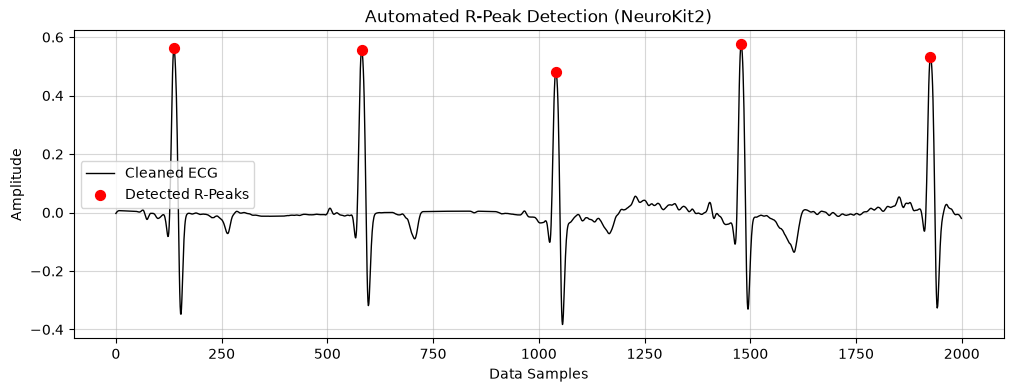

In [7]:
# --- 1. Load a Single Record ---
sami_dir = 'samitrop_wfdb/'
# Use recursive glob to find the files in the subfolders just like last week
sami_records = sorted([f.replace('.hea', '') for f in glob.glob(os.path.join(sami_dir, '**/*.hea'), recursive=True)])
record_path = sami_records[0]

rec = wfdb.rdrecord(record_path)
fs = rec.fs
lead_ii = rec.p_signal[:, 1]

# --- 2. Clean the Signal (NeuroKit2 does this automatically!) ---
# This single line replaces all our manual SciPy bandpass/notch filters
clean_signal = nk.ecg_clean(lead_ii, sampling_rate=fs)

# --- 3. Detect the R-Peaks ---
# This algorithm hunts for the massive spikes and records their exact locations
_, rpeaks = nk.ecg_peaks(clean_signal, sampling_rate=fs)

# --- 4. Plot to Verify ---
# We will zoom in on the first 5 seconds to make sure the AI marked the peaks correctly
plot_window = 5 * fs
window_signal = clean_signal[:plot_window]
window_peaks = rpeaks['ECG_R_Peaks'][rpeaks['ECG_R_Peaks'] < plot_window]

plt.figure(figsize=(12, 4))
plt.plot(window_signal, color='black', linewidth=1, label='Cleaned ECG')
# Overlay red dots exactly where the algorithm thinks the R-peaks are
plt.scatter(window_peaks, window_signal[window_peaks], color='red', s=50, zorder=3, label='Detected R-Peaks')

plt.title("Automated R-Peak Detection (NeuroKit2)")
plt.xlabel("Data Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [8]:
# --- 5. Compute RR intervals and HRV Features ---
# NeuroKit2 calculates dozens of HRV metrics at once from your rpeaks variable
hrv_metrics = nk.hrv(rpeaks, sampling_rate=fs)

# Extract the specific metrics requested for the assignment
mean_rr = hrv_metrics['HRV_MeanNN'].values[0] # Mean RR interval in milliseconds
sdnn = hrv_metrics['HRV_SDNN'].values[0]     # Standard deviation of RR intervals
rmssd = hrv_metrics['HRV_RMSSD'].values[0]   # Root mean square of successive differences

# Calculate average heart rate based on the Mean RR
heart_rate = 60000 / mean_rr 

print("--- Extracted Features ---")
print(f"Average Heart Rate: {heart_rate:.1f} BPM")
print(f"Mean RR Interval: {mean_rr:.1f} ms")
print(f"SDNN: {sdnn:.1f} ms")
print(f"RMSSD: {rmssd:.1f} ms")

--- Extracted Features ---
Average Heart Rate: 54.1 BPM
Mean RR Interval: 1109.6 ms
SDNN: 22.6 ms
RMSSD: 31.9 ms


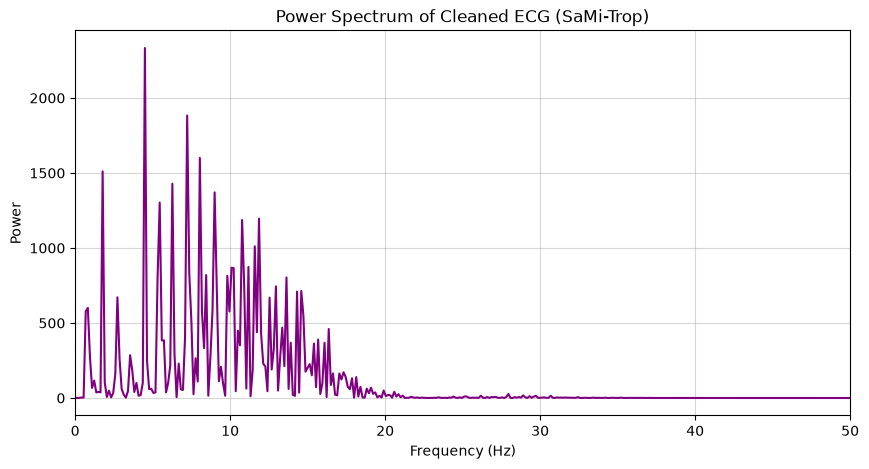

In [9]:
from scipy.fft import rfft, rfftfreq

# --- 6. Compute FFT and Plot Power Spectrum ---
# We use the 'clean_signal' you generated in the first step
N = len(clean_signal)

# Compute the Fast Fourier Transform
yf = rfft(clean_signal)
# Get the corresponding frequencies for the x-axis
xf = rfftfreq(N, 1 / fs)

# Calculate the actual power spectrum (magnitude squared)
power_spectrum = np.abs(yf)**2

plt.figure(figsize=(10, 5))
# Plot the frequencies. We zoom in on 0 to 50 Hz since we filtered out everything else last week!
plt.plot(xf, power_spectrum, color='purple', linewidth=1.5)
plt.xlim(0, 50) 
plt.title("Power Spectrum of Cleaned ECG (SaMi-Trop)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.grid(True, alpha=0.5)
plt.show()

In [10]:
import warnings
# Suppress those NeuroKit2 complexity warnings since our clips are short
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- 7. The Feature Extraction Function ---
def extract_features(record_path, label):
    try:
        # Load and clean
        rec = wfdb.rdrecord(record_path)
        fs = rec.fs
        # Use lead II and clean it
        clean_signal = nk.ecg_clean(rec.p_signal[:, 1], sampling_rate=fs)
        
        # Find peaks
        _, rpeaks = nk.ecg_peaks(clean_signal, sampling_rate=fs)
        
        # Calculate HRV
        hrv_metrics = nk.hrv(rpeaks, sampling_rate=fs)
        
        # Extract features safely
        mean_rr = hrv_metrics['HRV_MeanNN'].values[0] if 'HRV_MeanNN' in hrv_metrics else np.nan
        sdnn = hrv_metrics['HRV_SDNN'].values[0] if 'HRV_SDNN' in hrv_metrics else np.nan
        rmssd = hrv_metrics['HRV_RMSSD'].values[0] if 'HRV_RMSSD' in hrv_metrics else np.nan
        
        # Heart rate
        hr = 60000 / mean_rr if mean_rr > 0 else np.nan
        
        # QRS Duration approximation (using NeuroKit's delineate function)
        # We process just a small window to save time and avoid edge errors
        _, waves = nk.ecg_delineate(clean_signal, rpeaks, sampling_rate=fs, method="dwt")
        
        # Calculate average QRS width (R-offset minus R-onset)
        qrs_onsets = waves['ECG_R_Onsets']
        qrs_offsets = waves['ECG_R_Offsets']
        
        # Filter out NaNs to get a clean average
        valid_widths = []
        for on, off in zip(qrs_onsets, qrs_offsets):
            if not np.isnan(on) and not np.isnan(off):
                valid_widths.append((off - on) / fs * 1000) # Convert to milliseconds
                
        avg_qrs_duration = np.nanmean(valid_widths) if valid_widths else np.nan

        return {
            'ID': os.path.basename(record_path),
            'Mean_RR_ms': mean_rr,
            'SDNN_ms': sdnn,
            'RMSSD_ms': rmssd,
            'Heart_Rate_BPM': hr,
            'QRS_Duration_ms': avg_qrs_duration,
            'Label': label # 1 for Chagas, 0 for Healthy
        }
    except Exception as e:
        # If a record is too corrupted to process, skip it gracefully
        return None

# --- 8. Process the Dataset ---
print("Extracting features from 100 SaMi-Trop (Positive) records...")
positive_data = [extract_features(p, label=1) for p in sami_records[:100]]

print("Extracting features from 100 PTB-XL (Negative) records...")
# Use the recursive glob for ptb_dir just like we did for sami_dir
ptb_dir = 'ptbxl_wfdb/'
ptb_records = sorted([f.replace('.hea', '') for f in glob.glob(os.path.join(ptb_dir, '**/*.hea'), recursive=True)])
negative_data = [extract_features(p, label=0) for p in ptb_records[:100]]

# --- 9. Save to CSV ---
# Filter out any 'None' results from corrupted files, combine, and save
all_data = [d for d in positive_data + negative_data if d is not None]
df = pd.DataFrame(all_data)
df.to_csv('ecg_features.csv', index=False)

print(f"\nSuccess! Extracted features for {len(df)} patients and saved to 'ecg_features.csv'.")

Extracting features from 100 SaMi-Trop (Positive) records...
Extracting features from 100 PTB-XL (Negative) records...

Success! Extracted features for 198 patients and saved to 'ecg_features.csv'.


C:\Users\oabou\AppData\Local\Temp\ipykernel_1728\2371513368.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='QRS_Duration_ms', data=df, ax=axes[0], palette=['blue', 'red'])
C:\Users\oabou\AppData\Local\Temp\ipykernel_1728\2371513368.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Healthy (0)', 'Chagas (1)'])
C:\Users\oabou\AppData\Local\Temp\ipykernel_1728\2371513368.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='Heart_Rate_BPM', data=df, ax=axes[1], palette=['blue', 'red'])
C:\Users\oabou\AppData\Local\

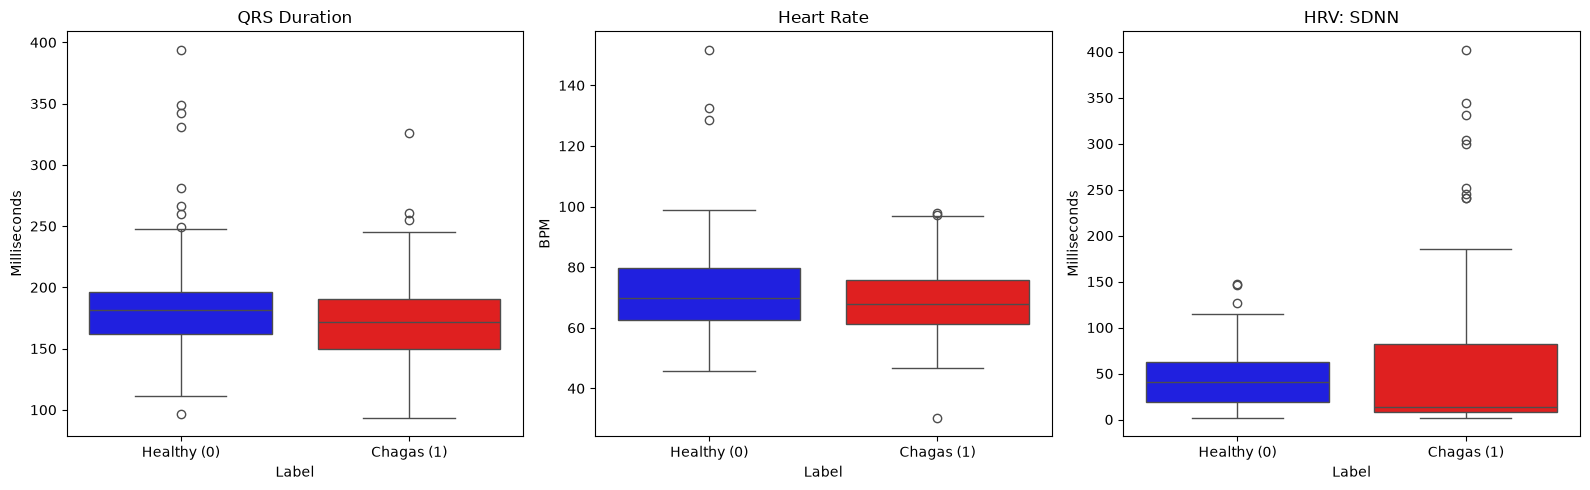

In [12]:
import seaborn as sns

# --- 10. Visualizing Feature Distributions ---
# Load the massive CSV you just generated
df = pd.read_csv('ecg_features.csv')

# Drop any rows where the math failed (NaNs)
df = df.dropna()

# Set up a 1x3 grid for our plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: QRS Duration (Conduction Delay)
sns.boxplot(x='Label', y='QRS_Duration_ms', data=df, ax=axes[0], palette=['blue', 'red'])
axes[0].set_title('QRS Duration')
axes[0].set_xticklabels(['Healthy (0)', 'Chagas (1)'])
axes[0].set_ylabel('Milliseconds')

# Plot 2: Heart Rate
sns.boxplot(x='Label', y='Heart_Rate_BPM', data=df, ax=axes[1], palette=['blue', 'red'])
axes[1].set_title('Heart Rate')
axes[1].set_xticklabels(['Healthy (0)', 'Chagas (1)'])
axes[1].set_ylabel('BPM')

# Plot 3: Heart Rate Variability (SDNN)
sns.boxplot(x='Label', y='SDNN_ms', data=df, ax=axes[2], palette=['blue', 'red'])
axes[2].set_title('HRV: SDNN')
axes[2].set_xticklabels(['Healthy (0)', 'Chagas (1)'])
axes[2].set_ylabel('Milliseconds')

plt.tight_layout()
plt.show()